## Count Objects in an Image
Now let’s see how to use the cvlib library to count the number of objects in an image using the Python programming language. I will first read an image by using the OpenCV library, then I will detect all the objects using cvlib and count the number of particular objects. The image that I am going to use for this task is shown below.

In [2]:
#!pip install cvlib

cvlib cache cleared.
Model files ensured.
Using CPU backend and target.


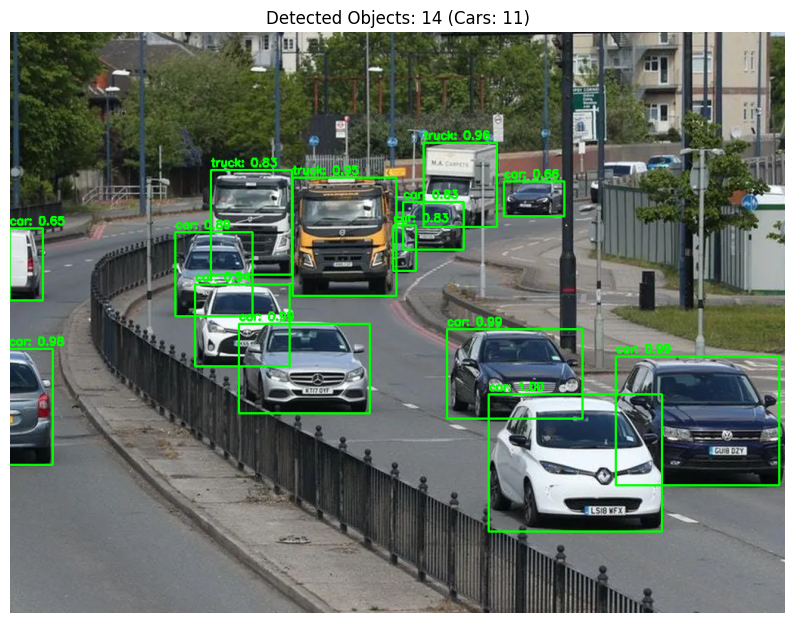

Number of cars in this image are 11


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# Define paths for YOLOv4 models
cvlib_model_dir = os.path.expanduser('~/.cvlib/object_detection/yolo') # Using cvlib's default path for consistency
yolov4_cfg_path = os.path.join(cvlib_model_dir, 'yolov4.cfg')
yolov4_weights_path = os.path.join(cvlib_model_dir, 'yolov4.weights')
labels_path = os.path.join(cvlib_model_dir, 'coco.names')

# Clear cvlib cache (optional, but good for a clean state before manual download)
if os.path.exists(os.path.expanduser('~/.cvlib')):
    shutil.rmtree(os.path.expanduser('~/.cvlib'))
    print("cvlib cache cleared.")

# Ensure the model directory exists
os.makedirs(cvlib_model_dir, exist_ok=True)

# Manually download yolov4.cfg if not present
if not os.path.exists(yolov4_cfg_path):
    print(f"Downloading yolov4.cfg to {yolov4_cfg_path}...")
    !wget -q https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg -O {yolov4_cfg_path}

# Manually download yolov4.weights if not present
if not os.path.exists(yolov4_weights_path):
    print(f"Downloading yolov4.weights to {yolov4_weights_path}...")
    # This is a large file, so it might take some time.
    !wget -q https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights -O {yolov4_weights_path}

# Manually download coco.names (labels) if not present
if not os.path.exists(labels_path):
    print(f"Downloading coco.names to {labels_path}...")
    !wget -q https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names -O {labels_path}

print("Model files ensured.")

# --- Start of custom object detection logic using OpenCV DNN ---

def detect_cars(image_path):
    # Load COCO names (class labels)
    with open(labels_path, 'r') as f:
        LABELS = [line.strip() for line in f.readlines()]

    # Load Yolo
    net = cv2.dnn.readNet(yolov4_weights_path, yolov4_cfg_path)

    # Set preferred backend and target (Explicitly set to CPU to avoid CUDA errors)
    net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
    net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
    print("Using CPU backend and target.")

    # Get output layer names
    output_layers_names = net.getUnconnectedOutLayersNames()

    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image. Make sure '{image_path}' exists.")
        return

    (H, W) = image.shape[:2]

    # Preprocess image for YOLO
    blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)
    layer_outputs = net.forward(output_layers_names)

    boxes = []
    confidences = []
    classIDs = []

    # Loop over each of the layer outputs
    for output in layer_outputs:
        # Loop over each of the detections
        for detection in output:
            scores = detection[5:]
            classID = np.argmax(scores)
            confidence = scores[classID]

            if confidence > 0.5: # Filter out weak predictions
                # Scale the bounding box coordinates back to the original image size
                box = detection[0:4] * np.array([W, H, W, H])
                (centerX, centerY, width, height) = box.astype("int")

                # Use the center (x, y)-coordinates to derive the top and left corner of the bounding box
                x = int(centerX - (width / 2))
                y = int(centerY - (height / 2))

                boxes.append([x, y, int(width), int(height)])
                confidences.append(float(confidence))
                classIDs.append(classID)

    # Apply non-maxima suppression to suppress weak, overlapping bounding boxes
    idxs = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.3) # confidence threshold, NMS threshold

    # Initialize lists to store detected labels and boxes for drawing
    detected_labels = []

    # Ensure at least one detection exists
    if len(idxs) > 0:
        # Loop over the indexes we are keeping
        for i in idxs.flatten():
            x, y, w, h = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]
            label = str(LABELS[classIDs[i]])
            confidence = confidences[i]

            detected_labels.append(label)

            # Draw bounding box and label
            color = (0, 255, 0) # Green color for bounding box
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
            text = f"{label}: {confidence:.2f}"
            cv2.putText(image, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Count cars
    car_count = detected_labels.count('car')

    # Display output
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off') # Hide axes
    plt.title(f"Detected Objects: {len(detected_labels)} (Cars: {car_count})")
    plt.show()
    print("Number of cars in this image are " + str(car_count))


# Kullanım
detect_cars("cars.jpeg")